In [1]:
import sys
sys.path.append("./Main/src")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from models_cl import CollectiveLearningModel

<Axes: title={'center': '50 agents, 1225 ties'}>

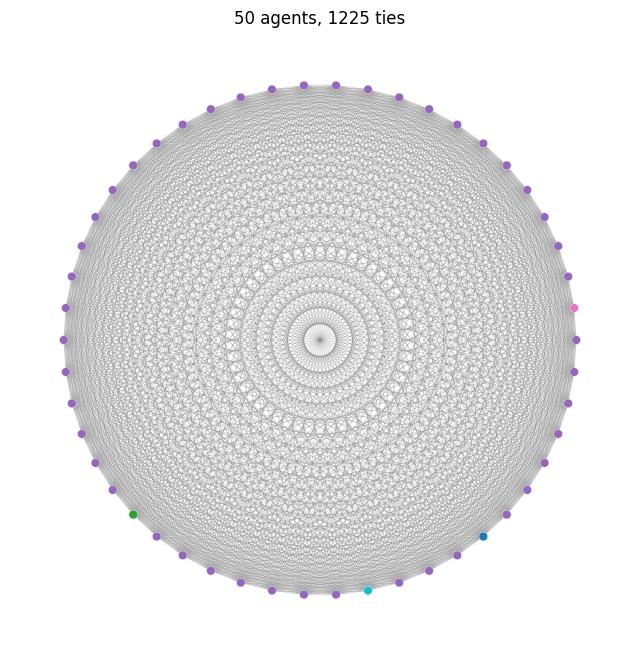

In [7]:
scenario = "consensus"

model = CollectiveLearningModel(
    n_agents=50,
    n_choices=6,
    network_type=scenario,
    alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
    consensus_threshold=1.0,
    seed=1
)

for agent in model.agents_list:
    agent.sampling = True

for i in range(NUM_ALL_CYCLE_ROUNDS):
    model.step()

model.draw_network()

<Axes: title={'center': '6 agents, 5 ties'}>

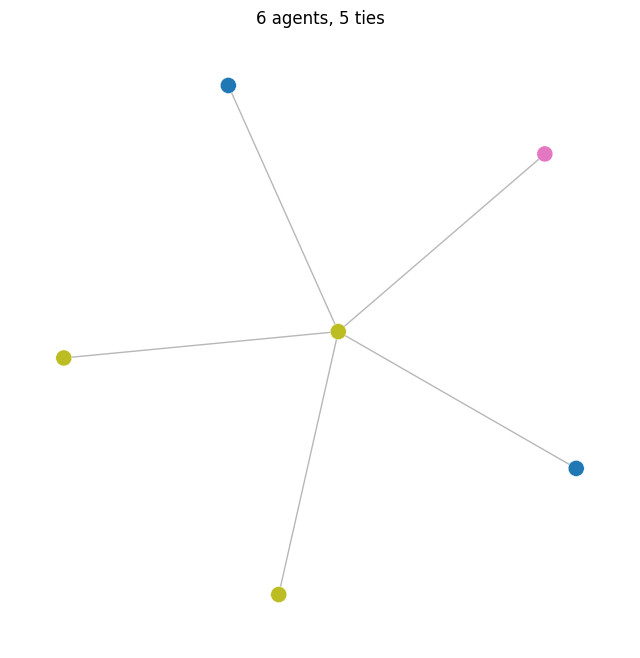

In [12]:
scenario = "consultative"

model = CollectiveLearningModel(
    n_agents=5,
    n_choices=6,
    network_type=scenario,
    alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
    consensus_threshold=1.0,
    seed=1
)

for agent in model.agents_list:
    agent.sampling = True

for i in range(NUM_ALL_CYCLE_ROUNDS):
    model.step()

model.draw_network()

In [17]:
agent = model.agents_list[4]
model.grid.get_neighbors(agent.node)

In [2]:
list_df = []
NUM_ALL_CYCLE_ROUNDS = 1
NUM_SIMULATIONS = 30
NUM_ALLIGNMENT_ROUNDS = 10

scenario = "consensus"

#-------------------------------
# CONSENSUS WITH TEMPERATURE 0
#-------------------------------
for seed in range(NUM_SIMULATIONS):
    model = CollectiveLearningModel(
        n_agents=50,
        n_choices=6,
        network_type=scenario,
        alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
        consensus_threshold=1.0,
        seed=seed
    )

    for i in range(NUM_ALL_CYCLE_ROUNDS):
        model.step()

    df = model.datacollector.get_model_vars_dataframe() 
    df["Seed"] = seed
    df["Structure"] = "Consensus (temperature=0)"
    list_df.append(df)

#-------------------------------
# CONSENSUS WITH TEMPERATURE 1
#-------------------------------
for seed in range(NUM_SIMULATIONS):
    model = CollectiveLearningModel(
        n_agents=50,
        n_choices=6,
        network_type=scenario,
        alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
        consensus_threshold=1.0,
        seed=seed
    )

    for agent in model.agents_list:
        agent.sampling = True

    for i in range(NUM_ALL_CYCLE_ROUNDS):
        model.step()

    df = model.datacollector.get_model_vars_dataframe() 
    df["Seed"] = seed
    df["Structure"] = "Consensus (temperature=1)"
    list_df.append(df)

#-------------------------------
# CONSULTATIVE
#-------------------------------
scenario = "consultative"

for seed in range(NUM_SIMULATIONS):
    model = CollectiveLearningModel(
        n_agents=50,
        n_choices=6,
        network_type=scenario,
        alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
        consensus_threshold=1.0,
        seed=seed
    )

    for i in range(NUM_ALL_CYCLE_ROUNDS):
        model.step()

    df = model.datacollector.get_model_vars_dataframe() 
    df["Seed"] = seed
    df["Structure"] = "Consultative"
    list_df.append(df)

#-------------------------------
# AUTOCRATIC
#-------------------------------
scenario = "autocratic"

for seed in range(NUM_SIMULATIONS):
    model = CollectiveLearningModel(
        n_agents=50,
        n_choices=6,
        network_type=scenario,
        alignment_max_time=NUM_ALLIGNMENT_ROUNDS,
        consensus_threshold=1.0,
        seed=seed
    )

    for i in range(NUM_ALL_CYCLE_ROUNDS):
        model.step()

    df = model.datacollector.get_model_vars_dataframe() 
    df["Seed"] = seed
    df["Structure"] = "Autocratic"
    list_df.append(df)

df = pd.concat(list_df, ignore_index=True)

In [3]:
df.head(2)

,Scenario,Round,Alignment_round,Total_Puzzles,Total_Time,Mean_Puzzles_Solved,Consensus,Seed,Structure
0,consensus,0,1,0,0,0.0,0.44,0,Consensus (temperature=0)
1,consensus,0,2,0,0,0.0,0.68,0,Consensus (temperature=0)


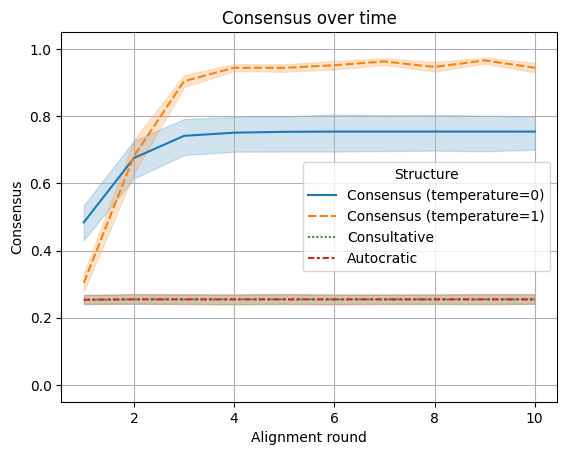

In [8]:
fig, ax = plt.subplots()

sns.lineplot(
    x="Alignment_round",
    y="Consensus",
    hue="Structure", style="Structure",
    data=df, ax=ax,
    errorbar=("ci", 95),
    # err_style="bars"
)

ax.set_title("Consensus over time")
ax.set_xlabel("Alignment round")
ax.set_ylabel("Consensus")
ax.set_ylim(-0.05, 1.05)
# ax.axhline(y=model.consensus_threshold, color="red", linestyle="--")
ax.grid()
plt.show()